--- Executing Data Audit ---
     Set   Total  Sepsis_Cases  Prevalence
0  train   45717         30178    0.660105
1    val   51082          5787    0.113288
2   test  617005          7682    0.012450


C:\Users\96277\AppData\Local\Temp\ipykernel_21756\655629107.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=audit_df, x='Set', y='Prevalence', palette='viridis')


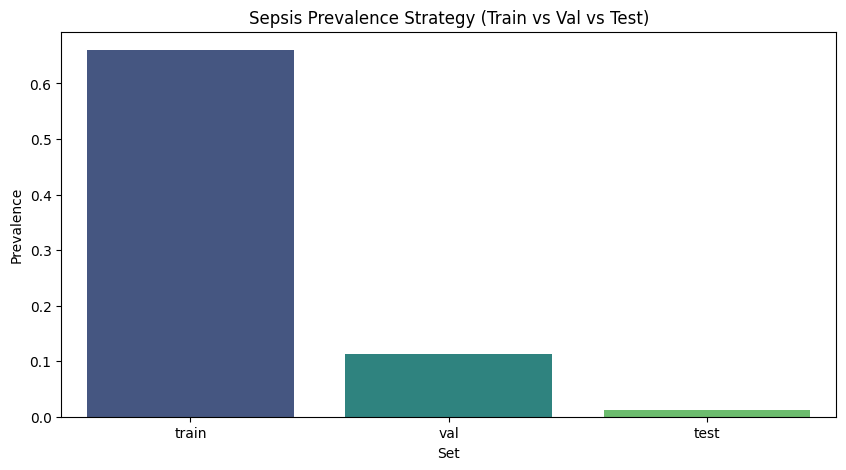

--- Running UMAP Projection (Sampling 10000 points) ---


c:\Users\96277\anaconda3\envs\nicu-sepsis\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


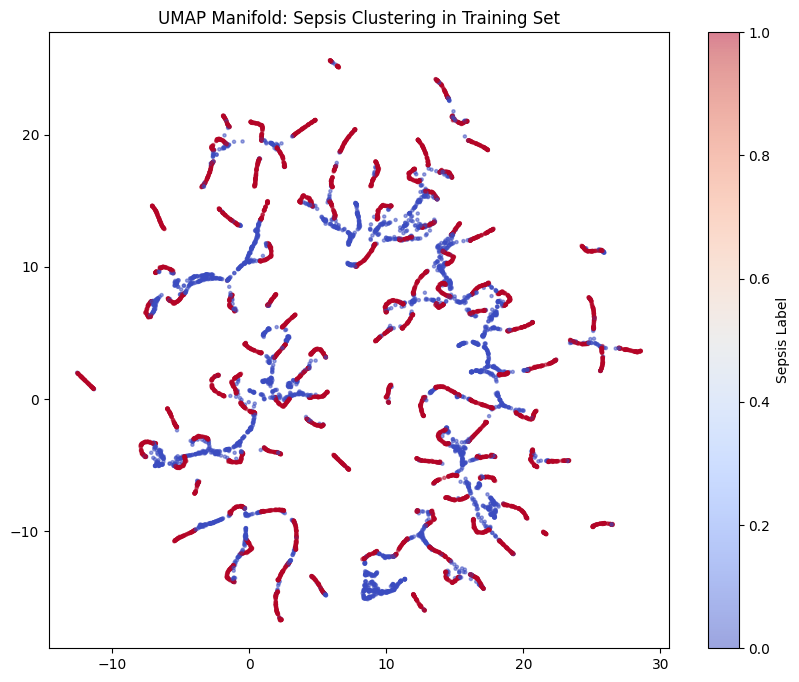

--- Calculating Statistical Feature Importance (Mutual Information) ---


C:\Users\96277\AppData\Local\Temp\ipykernel_21756\655629107.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df.head(15), x='MI_Score', y='Feature', palette='rocket')


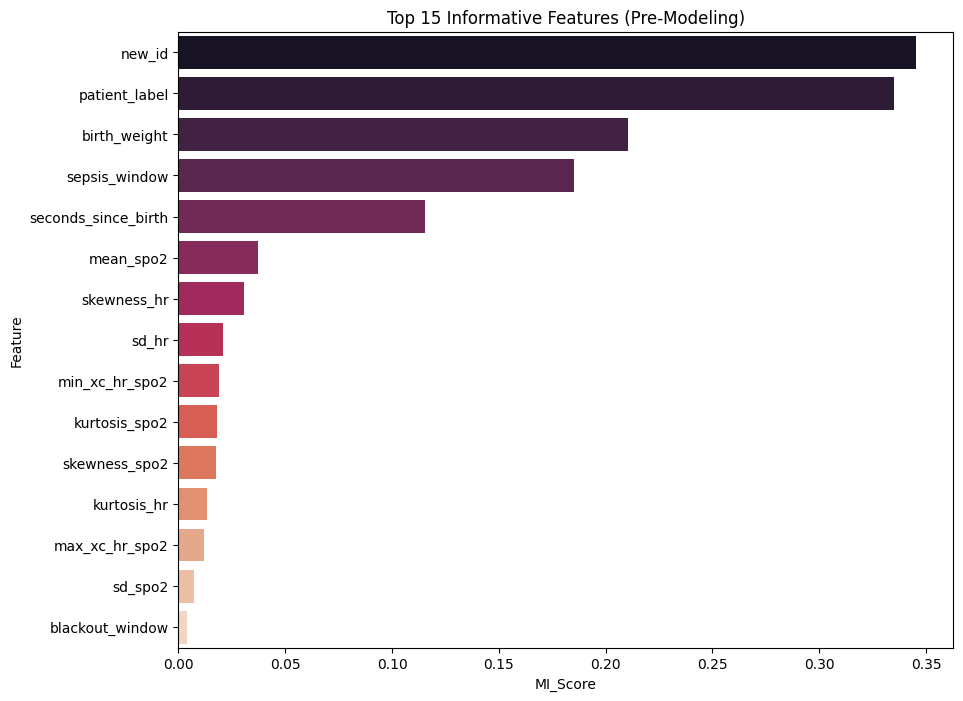

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import umap
from sklearn.feature_selection import mutual_info_classif
from pathlib import Path

# ==========================================
# 1. CONFIGURATION & DATA LOADING
# ==========================================
DATA_DIR = Path("data/processed/splits_by_patient")

FILES = {
    "train": "train_forecast24_undersampled005_patientaware.csv",
    "val": "val_forecast24_balanced20.csv",
    "test": "test_forecast24.csv"
}

# Dictionary to hold dataframes
dfs = {name: pd.read_csv(DATA_DIR / filename) for name, filename in FILES.items()}

# Define common columns - ADJUST NAMES IF DIFFERENT IN YOUR CSV
TARGET = 'y_forecast_24h'
ID_COL = 'Patient_ID'
TIME_COL = 'Hour'

# ==========================================
# 2. FEATURE SELECTION (Auto-detect numeric)
# ==========================================
# Drop non-feature columns for analysis
def get_features(df):
    cols_to_drop = [TARGET, ID_COL, TIME_COL]
    return df.select_dtypes(include=[np.number]).drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

# ==========================================
# 3. ANALYSIS MODULES
# ==========================================

def run_strategic_audit():
    print("--- Executing Data Audit ---")
    audit_data = []
    for name, df in dfs.items():
        count = len(df)
        pos = df[TARGET].sum()
        audit_data.append({"Set": name, "Total": count, "Sepsis_Cases": pos, "Prevalence": pos/count})
    
    audit_df = pd.DataFrame(audit_data)
    print(audit_df)
    
    # Plot Class Distribution
    plt.figure(figsize=(10, 5))
    sns.barplot(data=audit_df, x='Set', y='Prevalence', palette='viridis')
    plt.title("Sepsis Prevalence Strategy (Train vs Val vs Test)")
    plt.show()

def run_high_dim_visualization(n_samples=10000):
    print(f"--- Running UMAP Projection (Sampling {n_samples} points) ---")
    train_df = dfs['train'].sample(n=min(n_samples, len(dfs['train'])), random_state=42)
    X = get_features(train_df).fillna(0)
    y = train_df[TARGET]
    
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=42)
    embedding = reducer.fit_transform(X)
    
    plt.figure(figsize=(10, 8))
    plt.scatter(embedding[:, 0], embedding[:, 1], c=y, cmap='coolwarm', s=5, alpha=0.5)
    plt.colorbar(label='Sepsis Label')
    plt.title("UMAP Manifold: Sepsis Clustering in Training Set")
    plt.show()

def run_feature_importance():
    print("--- Calculating Statistical Feature Importance (Mutual Information) ---")
    # Using a sample for speed
    sample = dfs['train'].sample(n=min(5000, len(dfs['train'])), random_state=42)
    X = get_features(sample).fillna(0)
    y = sample[TARGET]
    
    mi_scores = mutual_info_classif(X, y, discrete_features='auto', random_state=42)
    mi_df = pd.DataFrame({'Feature': X.columns, 'MI_Score': mi_scores}).sort_values('MI_Score', ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=mi_df.head(15), x='MI_Score', y='Feature', palette='rocket')
    plt.title("Top 15 Informative Features (Pre-Modeling)")
    plt.show()
    return mi_df

def plot_patient_trajectory(patient_id=None):
    print(f"--- Plotting Patient Trajectory ---")
    test_df = dfs['test']
    if patient_id is None:
        # Auto-pick a sepsis patient from test set
        patient_id = test_df[test_df[TARGET] == 1][ID_COL].iloc[0]
    
    p_data = test_df[test_df[ID_COL] == patient_id].sort_values(TIME_COL)
    
    # Select 3 key vitals dynamically
    vitals = [c for c in ['HR', 'O2Sat', 'Temp', 'MAP'] if c in p_data.columns][:3]
    
    fig = make_subplots(rows=len(vitals), cols=1, shared_xaxes=True, vertical_spacing=0.05)
    for i, v in enumerate(vitals):
        fig.add_trace(go.Scatter(x=p_data[TIME_COL], y=p_data[v], name=v, mode='lines+markers'), row=i+1, col=1)
        # Prediction window highlight (last 24h)
        max_h = p_data[TIME_COL].max()
        fig.add_vrect(x0=max_h-24, x1=max_h, fillcolor="orange", opacity=0.1, line_width=0, row=i+1, col=1)

    fig.update_layout(height=600, title_text=f"Sepsis Prediction Window: Patient {patient_id}")
    fig.show()

# ==========================================
# 4. EXECUTION
# ==========================================
run_strategic_audit()
run_high_dim_visualization()
important_features = run_feature_importance()
# plot_patient_trajectory() # Uncomment after verifying column names

<Axes: xlabel='mean_hr', ylabel='Density'>

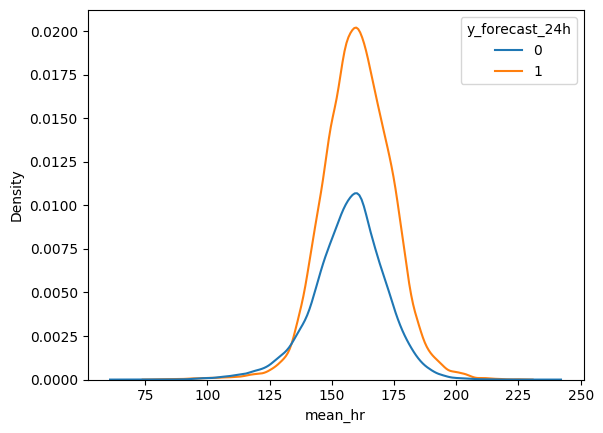

In [8]:
sns.kdeplot(data=train_df, x="mean_hr", hue="y_forecast_24h")

In [9]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from pathlib import Path
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap.umap_ as umap

In [10]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from pathlib import Path
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap.umap_ as umap

In [11]:
DATA_DIR = Path("data/processed/splits_by_patient")

FILES = {
    "train": "train_forecast24_undersampled005_patientaware.csv",
    "val": "val_forecast24.csv",
    "test": "test_forecast24.csv"
}

dfs = {name: pd.read_csv(DATA_DIR / file) for name, file in FILES.items()}

for name, df in dfs.items():
    print(f"{name.upper()} shape: {df.shape}")
    print(df.columns.tolist())
    print("-" * 80)

TRAIN shape: (45717, 19)
['new_id', 'seconds_since_birth', 'mean_hr', 'mean_spo2', 'sd_hr', 'sd_spo2', 'skewness_hr', 'skewness_spo2', 'kurtosis_hr', 'kurtosis_spo2', 'max_xc_hr_spo2', 'min_xc_hr_spo2', 'sub', 'sepsis_window', 'blackout_window', 'sex', 'birth_weight', 'y_forecast_24h', 'patient_label']
--------------------------------------------------------------------------------
VAL shape: (769979, 18)
['new_id', 'seconds_since_birth', 'mean_hr', 'mean_spo2', 'sd_hr', 'sd_spo2', 'skewness_hr', 'skewness_spo2', 'kurtosis_hr', 'kurtosis_spo2', 'max_xc_hr_spo2', 'min_xc_hr_spo2', 'sub', 'sepsis_window', 'blackout_window', 'sex', 'birth_weight', 'y_forecast_24h']
--------------------------------------------------------------------------------
TEST shape: (617005, 18)
['new_id', 'seconds_since_birth', 'mean_hr', 'mean_spo2', 'sd_hr', 'sd_spo2', 'skewness_hr', 'skewness_spo2', 'kurtosis_hr', 'kurtosis_spo2', 'max_xc_hr_spo2', 'min_xc_hr_spo2', 'sub', 'sepsis_window', 'blackout_window', 's

In [12]:
TARGET = "y_forecast_24h"
ID_COL = "new_id"
TIME_COL = "seconds_since_birth"

# columns that should NOT be used as input features
LEAKAGE_OR_META_COLS = [
    TARGET,
    "new_id",
    "patient_label",
    "seconds_since_birth"
]

In [13]:
def get_feature_columns(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in numeric_cols if c not in LEAKAGE_OR_META_COLS]
    return feature_cols

def get_X_y(df):
    feature_cols = get_feature_columns(df)
    X = df[feature_cols].copy()
    y = df[TARGET].copy()
    return X, y

feature_cols = get_feature_columns(dfs["train"])
print("Selected features:")
print(feature_cols)
print(f"\nTotal usable features: {len(feature_cols)}")

Selected features:
['mean_hr', 'mean_spo2', 'sd_hr', 'sd_spo2', 'skewness_hr', 'skewness_spo2', 'kurtosis_hr', 'kurtosis_spo2', 'max_xc_hr_spo2', 'min_xc_hr_spo2', 'sub', 'sepsis_window', 'blackout_window', 'sex', 'birth_weight']

Total usable features: 15


In [14]:
overview_rows = []

for split_name, df in dfs.items():
    n_rows = len(df)
    n_patients = df[ID_COL].nunique() if ID_COL in df.columns else np.nan
    prevalence = df[TARGET].mean() if TARGET in df.columns else np.nan
    avg_windows = n_rows / n_patients if pd.notnull(n_patients) and n_patients > 0 else np.nan
    
    overview_rows.append({
        "Split": split_name,
        "Rows": n_rows,
        "Patients": n_patients,
        "Features": len(feature_cols),
        "Sepsis Prevalence": prevalence,
        "Avg Windows/Patient": avg_windows
    })

overview_df = pd.DataFrame(overview_rows)
overview_df

,Split,Rows,Patients,Features,Sepsis Prevalence,Avg Windows/Patient
0,train,45717,306,15,0.660105,149.401961
1,val,769979,66,15,0.007516,11666.348485
2,test,617005,66,15,0.012450,9348.560606


In [15]:
fig = go.Figure()

fig.add_trace(go.Bar(
    x=overview_df["Split"],
    y=overview_df["Rows"],
    name="Rows"
))

fig.update_layout(
    title="Dataset Overview: Number of Records per Split",
    xaxis_title="Split",
    yaxis_title="Number of Rows",
    template="plotly_white",
    height=500
)

fig.show()

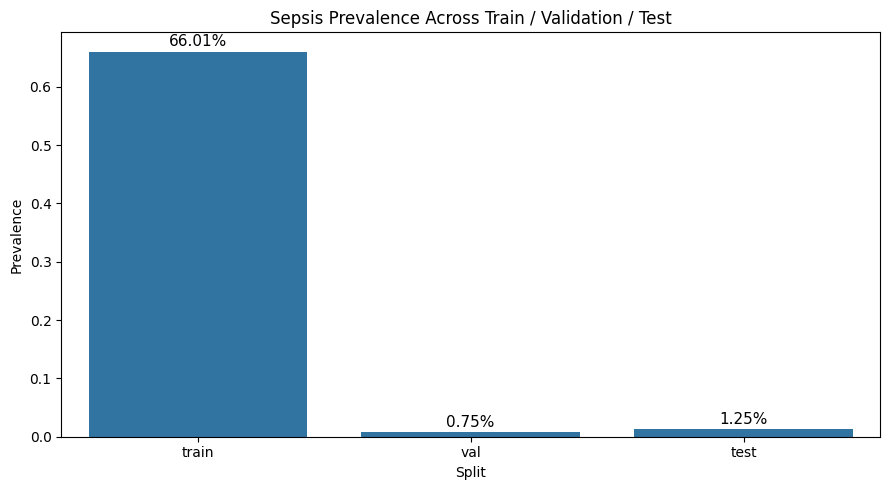

In [16]:
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=overview_df, x="Split", y="Sepsis Prevalence")

for i, v in enumerate(overview_df["Sepsis Prevalence"]):
    ax.text(i, v + 0.01, f"{v:.2%}", ha="center", fontsize=11)

plt.title("Sepsis Prevalence Across Train / Validation / Test")
plt.ylabel("Prevalence")
plt.xlabel("Split")
plt.tight_layout()
plt.show()

In [17]:
count_rows = []

for split_name, df in dfs.items():
    class_counts = df[TARGET].value_counts().sort_index()
    for cls, cnt in class_counts.items():
        count_rows.append({
            "Split": split_name,
            "Class": "Sepsis" if cls == 1 else "Non-Sepsis",
            "Count": cnt
        })

count_df = pd.DataFrame(count_rows)

fig = px.bar(
    count_df,
    x="Split",
    y="Count",
    color="Class",
    barmode="group",
    title="Class Distribution Across Splits",
    template="plotly_white"
)

fig.show()

In [18]:
missing_summary = []

for split_name, df in dfs.items():
    missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    for col, pct in missing_pct.items():
        missing_summary.append({
            "Split": split_name,
            "Column": col,
            "MissingPercent": pct
        })

missing_df = pd.DataFrame(missing_summary)
missing_df.head(20)

,Split,Column,MissingPercent
0,train,new_id,0.0
1,train,seconds_since_birth,0.0
2,train,mean_hr,0.0
3,train,mean_spo2,0.0
4,train,sd_hr,0.0
5,train,sd_spo2,0.0
6,train,skewness_hr,0.0
7,train,skewness_spo2,0.0
8,train,kurtosis_hr,0.0
9,train,kurtosis_spo2,0.0


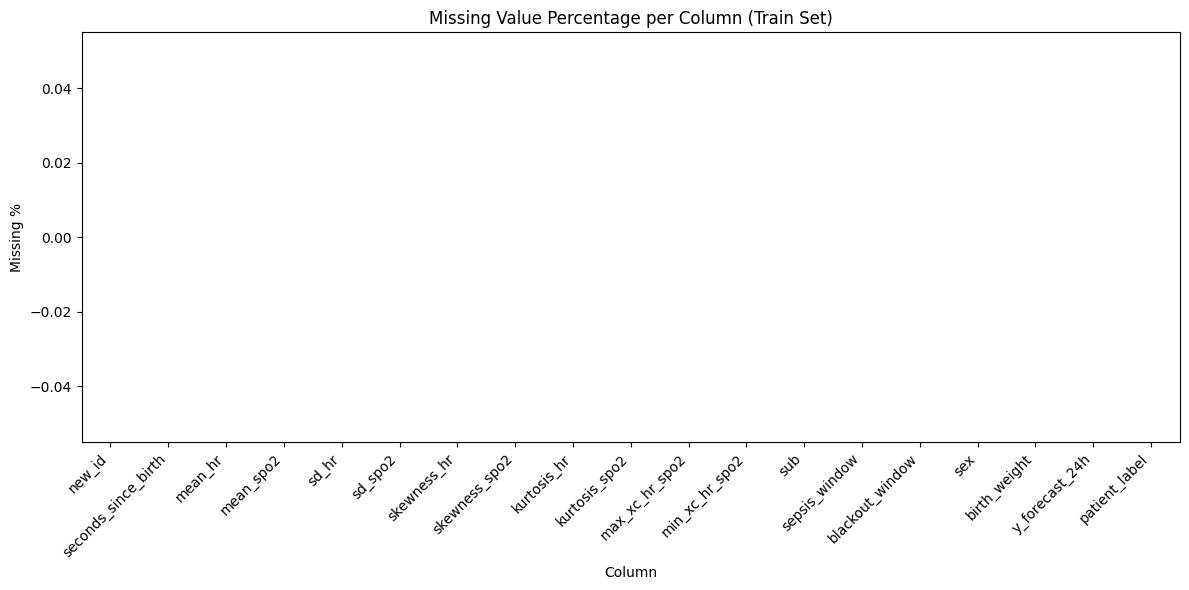

In [19]:
train_missing = (dfs["train"].isnull().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
train_missing.plot(kind="bar")
plt.title("Missing Value Percentage per Column (Train Set)")
plt.ylabel("Missing %")
plt.xlabel("Column")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [20]:
dfs["train"][feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
mean_hr,45717.0,159.157935,14.159976,67.265060,150.496552,159.410000,168.263333,235.722222
mean_spo2,45717.0,92.823771,5.114496,50.000000,90.250000,93.493333,96.536667,100.000000
sd_hr,45717.0,6.249782,4.487008,0.000000,3.368220,4.994896,7.619871,50.435819
sd_spo2,45717.0,3.134635,2.805583,0.000000,1.234126,2.329482,4.114260,35.036801
skewness_hr,45717.0,-0.663867,1.552270,-12.151528,-1.342045,-0.270021,0.328996,12.920937
skewness_spo2,45717.0,-1.059921,1.295882,-17.233785,-1.460338,-0.799895,-0.307090,10.654044
kurtosis_hr,45717.0,7.027683,8.786873,1.013855,2.669764,3.715917,7.341891,203.963098
kurtosis_spo2,45717.0,5.734648,10.322521,1.000178,2.471214,3.283222,5.318357,298.003344
max_xc_hr_spo2,45717.0,0.124848,0.314353,-0.848375,-0.077444,0.119646,0.331892,0.981444
min_xc_hr_spo2,45717.0,-0.220713,0.288200,-0.959625,-0.420515,-0.226067,-0.039378,0.878871


In [21]:
important_vis_features = [c for c in ["mean_hr", "mean_spo2", "sd_hr", "sd_spo2", "birth_weight"] if c in feature_cols]
important_vis_features

['mean_hr', 'mean_spo2', 'sd_hr', 'sd_spo2', 'birth_weight']

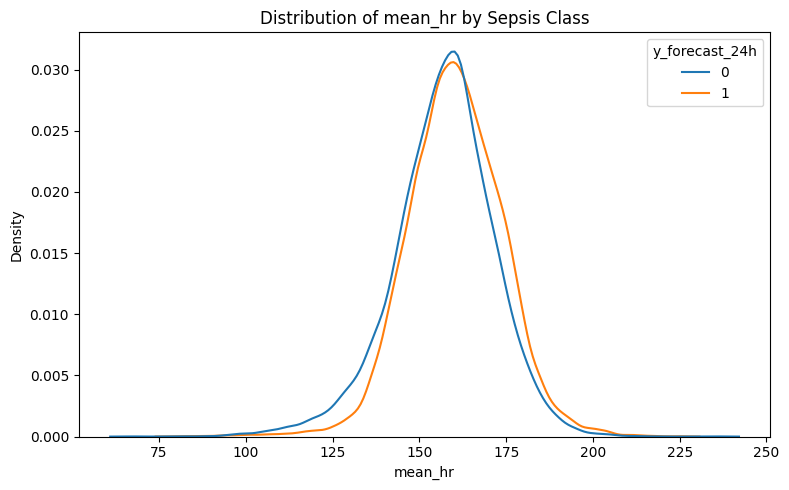

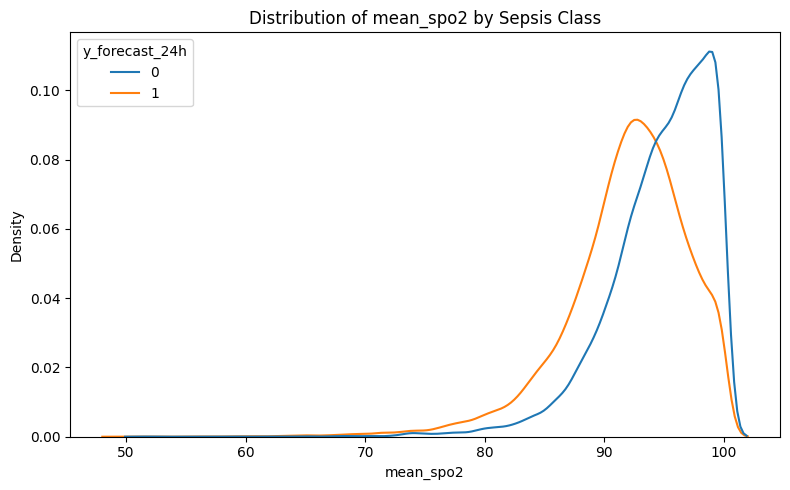

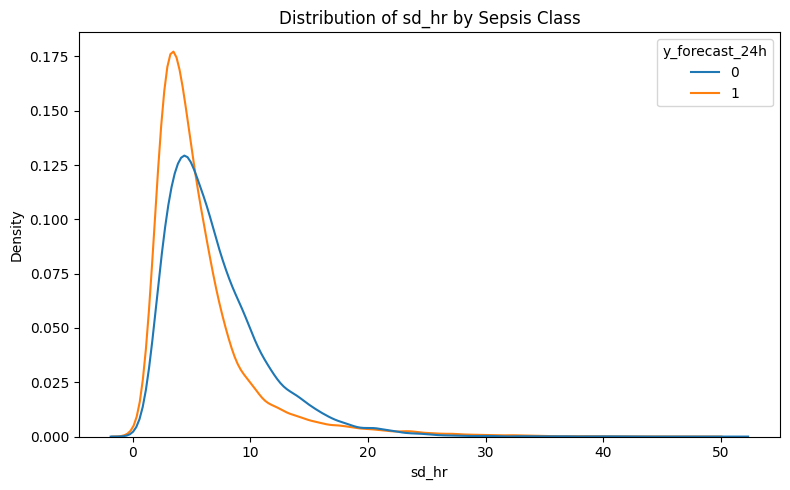

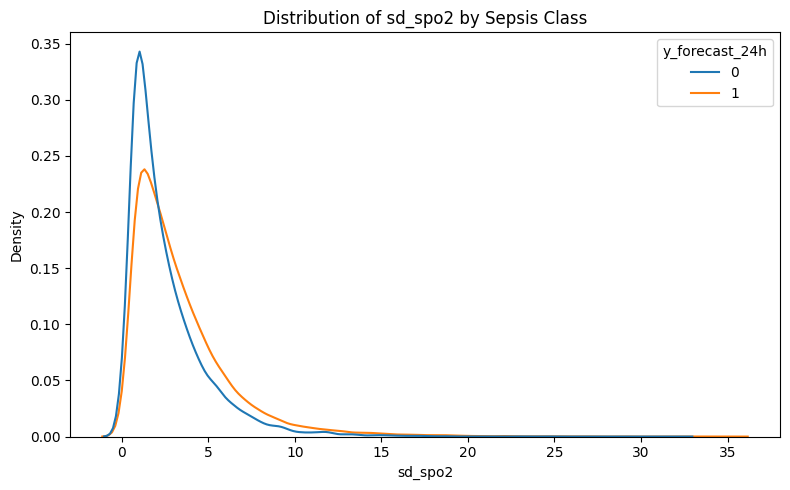

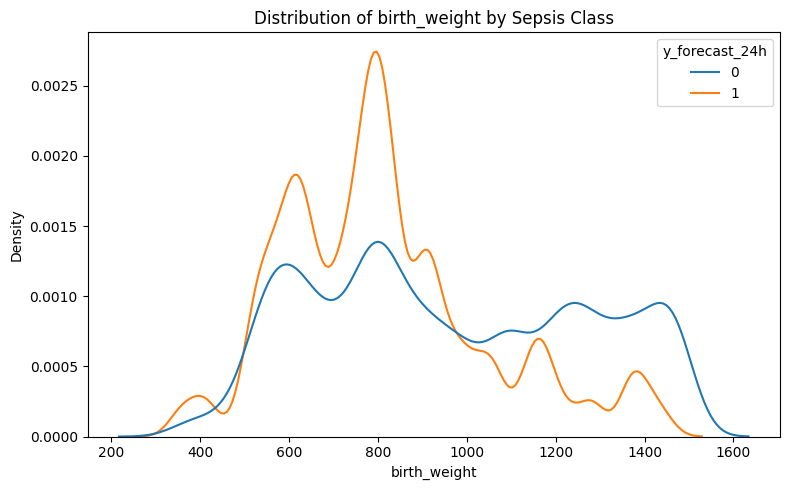

In [23]:
def plot_kde_by_class(df, feature):
    plt.figure(figsize=(8, 5))
    
    sns.kdeplot(data=df, x=feature, hue=TARGET, common_norm=False, fill=False)
    
    plt.title(f"Distribution of {feature} by Sepsis Class")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

for feat in important_vis_features:
    plot_kde_by_class(dfs["train"], feat)

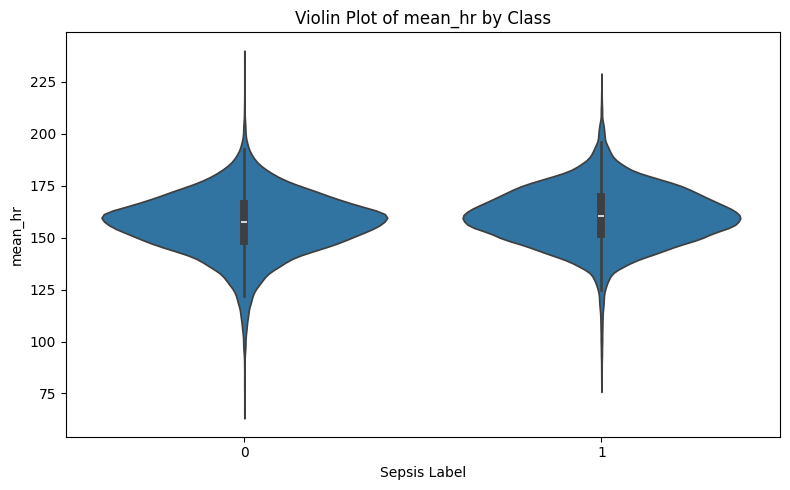

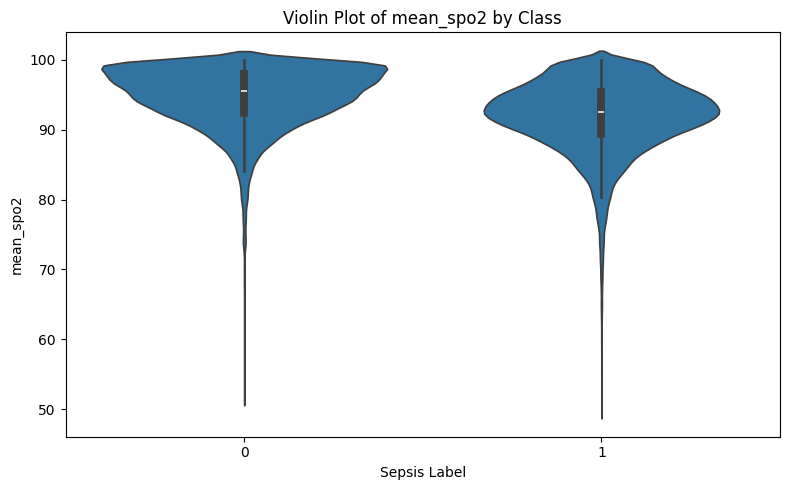

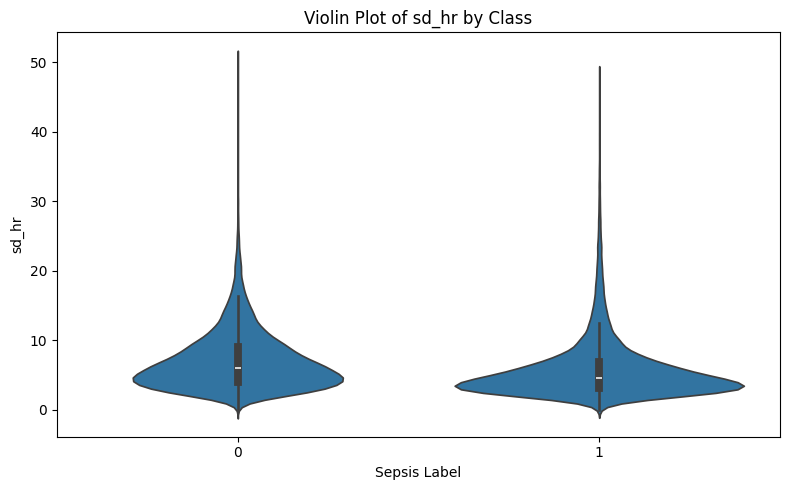

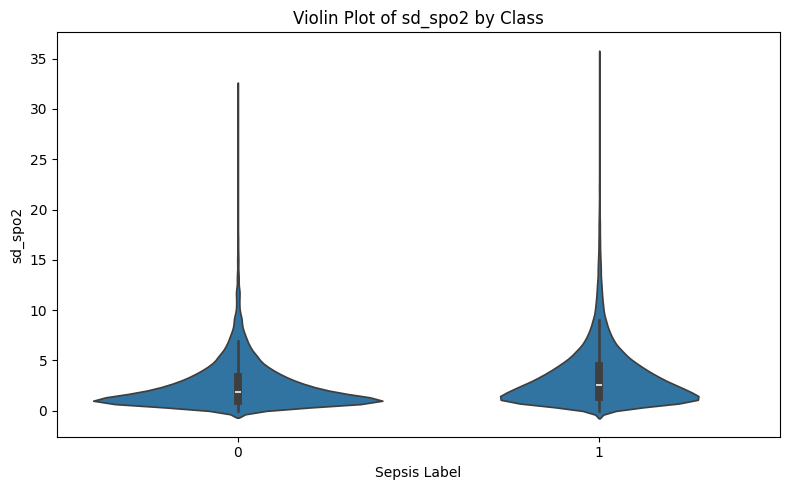

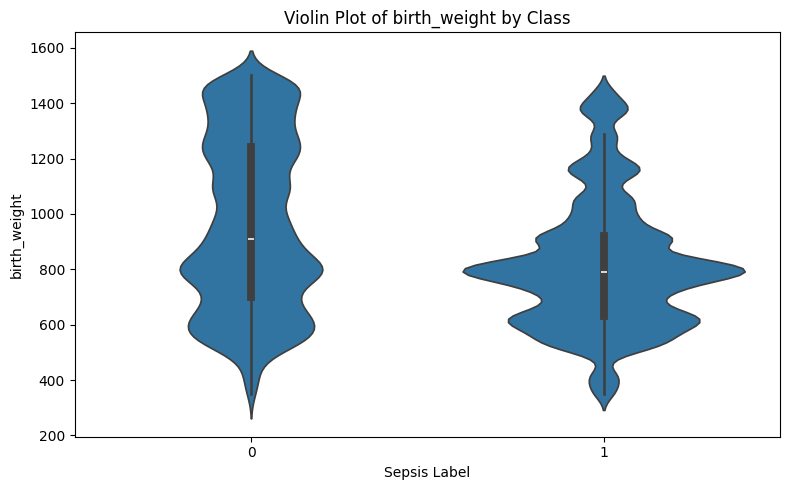

In [24]:
def plot_violin_by_class(df, feature):
    plt.figure(figsize=(8, 5))
    sns.violinplot(data=df, x=TARGET, y=feature)
    plt.title(f"Violin Plot of {feature} by Class")
    plt.xlabel("Sepsis Label")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

for feat in important_vis_features:
    plot_violin_by_class(dfs["train"], feat)
       

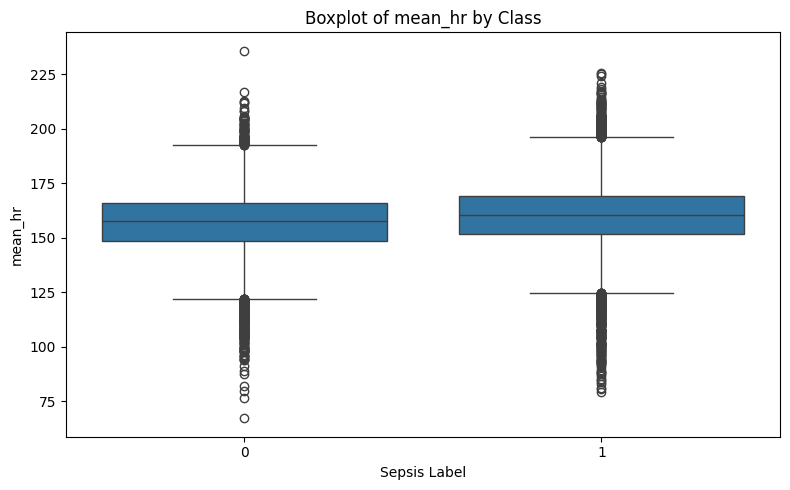

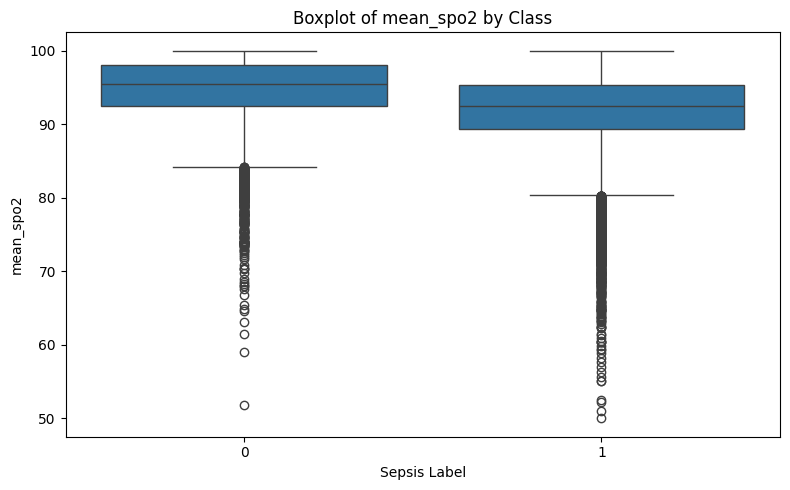

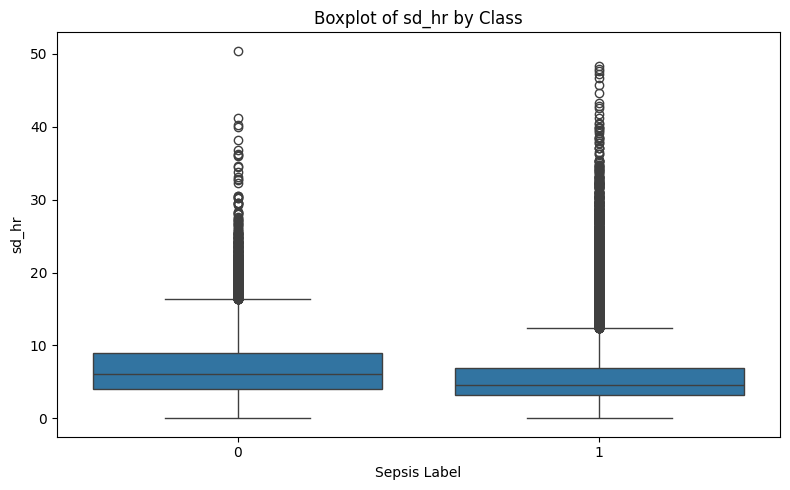

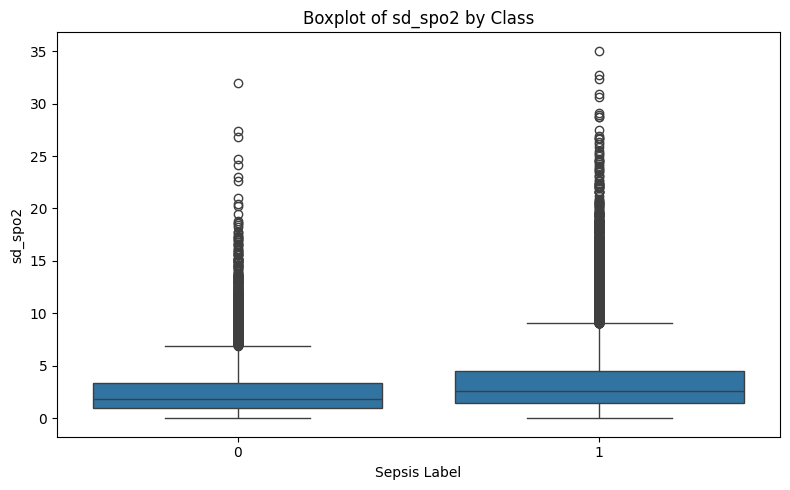

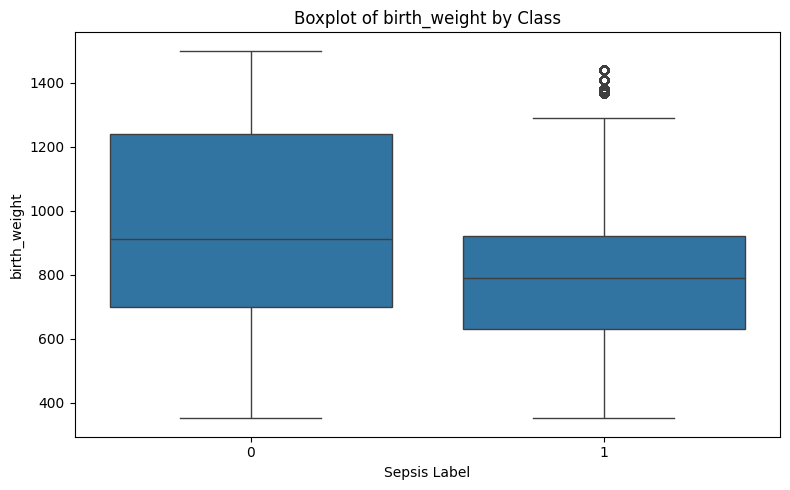

In [25]:
for feat in important_vis_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=dfs["train"], x=TARGET, y=feat)
    plt.title(f"Boxplot of {feat} by Class")
    plt.xlabel("Sepsis Label")
    plt.ylabel(feat)
    plt.tight_layout()
    plt.show()
    

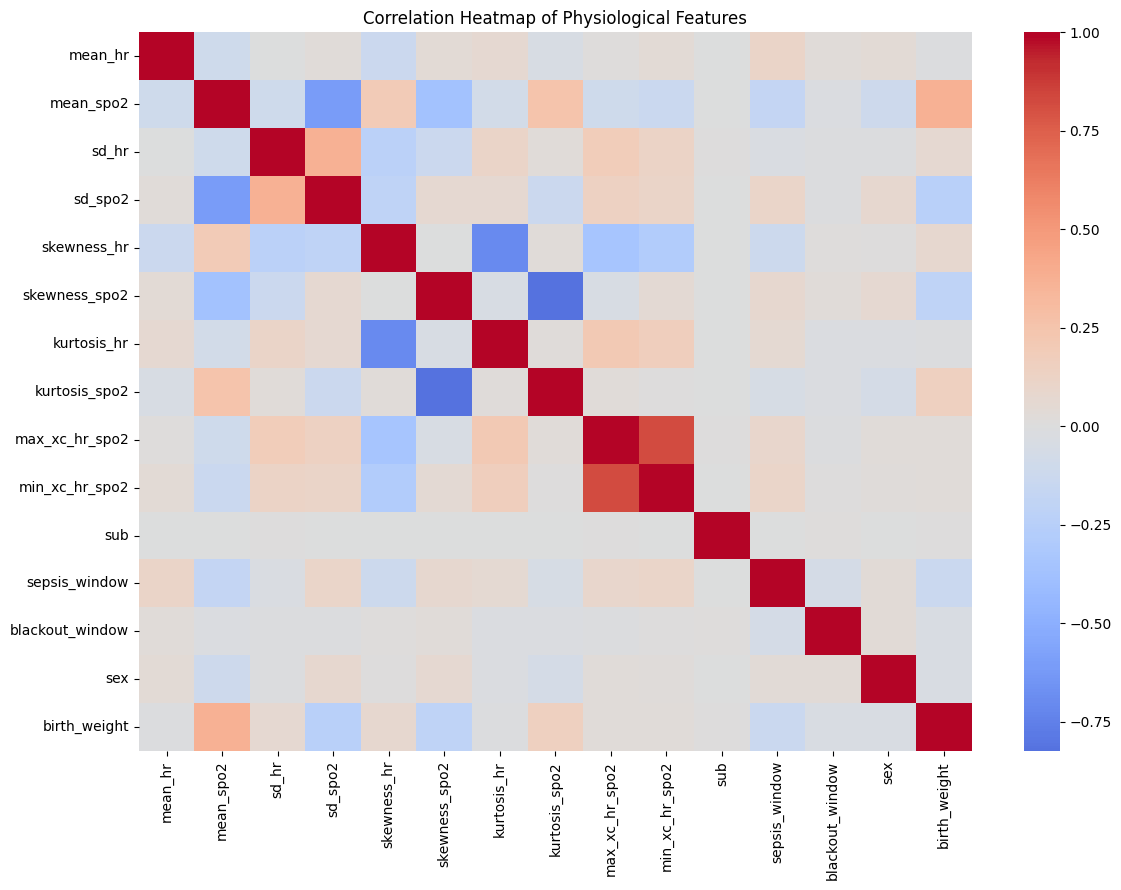

In [26]:
corr = dfs["train"][feature_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Physiological Features")
plt.tight_layout()
plt.show()

In [27]:
corr_abs = corr.abs().where(~np.eye(corr.shape[0], dtype=bool))
top_pairs = (
    corr_abs.unstack()
    .sort_values(ascending=False)
    .drop_duplicates()
    .reset_index()
)
top_pairs.columns = ["Feature_1", "Feature_2", "Abs_Correlation"]
top_pairs.head(15)

,Feature_1,Feature_2,Abs_Correlation
0,skewness_spo2,kurtosis_spo2,0.824452
1,max_xc_hr_spo2,min_xc_hr_spo2,0.815694
2,kurtosis_hr,skewness_hr,0.707660
3,mean_spo2,sd_spo2,0.617175
4,mean_spo2,birth_weight,0.372430
5,skewness_spo2,mean_spo2,0.372220
6,sd_hr,sd_spo2,0.370280
7,max_xc_hr_spo2,skewness_hr,0.342456
8,skewness_hr,min_xc_hr_spo2,0.289343
9,kurtosis_spo2,mean_spo2,0.257274


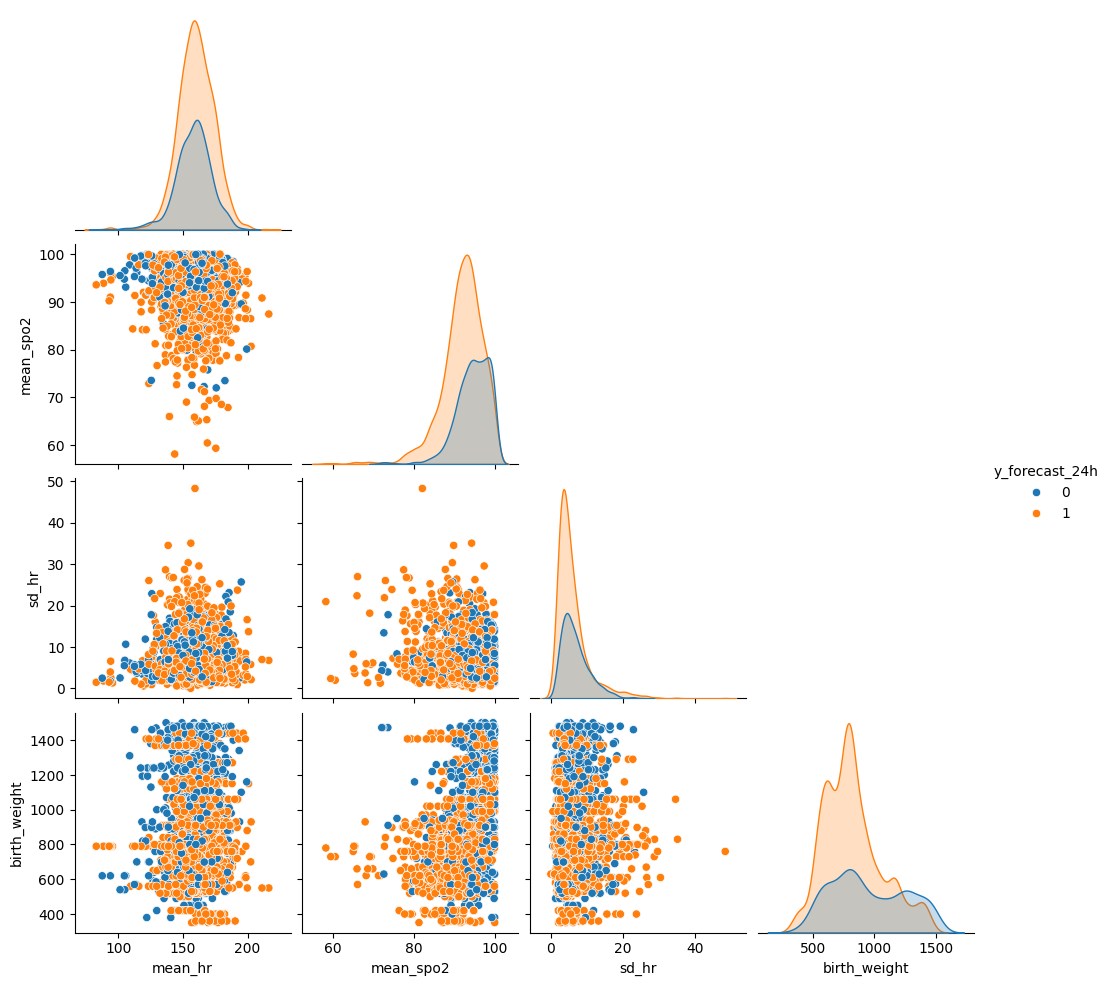

In [28]:
pairplot_features = [c for c in ["mean_hr", "mean_spo2", "sd_hr", "birth_weight"] if c in feature_cols]

pairplot_df = dfs["train"][pairplot_features + [TARGET]].sample(
    n=min(3000, len(dfs["train"])),
    random_state=42
)

sns.pairplot(pairplot_df, hue=TARGET, corner=True)
plt.show()

In [29]:
sample_df = dfs["train"].sample(n=min(5000, len(dfs["train"])), random_state=42)

X_mi = sample_df[feature_cols].fillna(0)
y_mi = sample_df[TARGET]

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)

mi_df = pd.DataFrame({
    "Feature": feature_cols,
    "MI_Score": mi_scores
}).sort_values("MI_Score", ascending=False)

mi_df

,Feature,MI_Score
14,birth_weight,0.212041
11,sepsis_window,0.185568
1,mean_spo2,0.037943
4,skewness_hr,0.030665
2,sd_hr,0.020942
9,min_xc_hr_spo2,0.019134
7,kurtosis_spo2,0.018360
5,skewness_spo2,0.017849
10,sub,0.017095
6,kurtosis_hr,0.013595


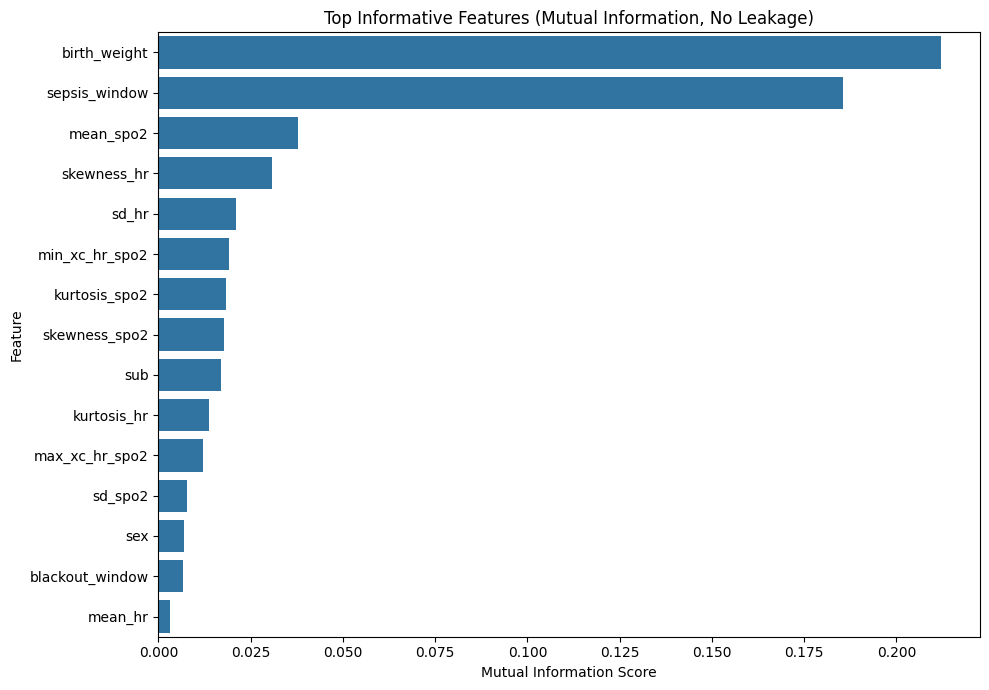

In [30]:
plt.figure(figsize=(10, 7))
sns.barplot(data=mi_df.head(15), x="MI_Score", y="Feature")
plt.title("Top Informative Features (Mutual Information, No Leakage)")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [31]:
sample_df = dfs["train"].sample(n=min(5000, len(dfs["train"])), random_state=42)

X_pca = sample_df[feature_cols].fillna(0)
y_pca = sample_df[TARGET]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

pca = PCA(n_components=2, random_state=42)
X_pca_2d = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "Class": y_pca.astype(str).values
})

fig = px.scatter(
    pca_df,
    x="PC1",
    y="PC2",
    color="Class",
    title="PCA Projection of Training Data",
    template="plotly_white",
    opacity=0.6
)

fig.show()

In [32]:
sample_df = dfs["train"].sample(n=min(7000, len(dfs["train"])), random_state=42)

X_umap = sample_df[feature_cols].fillna(0)
y_umap = sample_df[TARGET]

scaler = StandardScaler()
X_umap_scaled = scaler.fit_transform(X_umap)

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.2,
    metric="euclidean",
    random_state=42
)

embedding = reducer.fit_transform(X_umap_scaled)

umap_df = pd.DataFrame({
    "UMAP_1": embedding[:, 0],
    "UMAP_2": embedding[:, 1],
    "Class": y_umap.astype(str).values
})

fig = px.scatter(
    umap_df,
    x="UMAP_1",
    y="UMAP_2",
    color="Class",
    title="UMAP Projection of Physiological Features",
    template="plotly_white",
    opacity=0.6
)

fig.show()

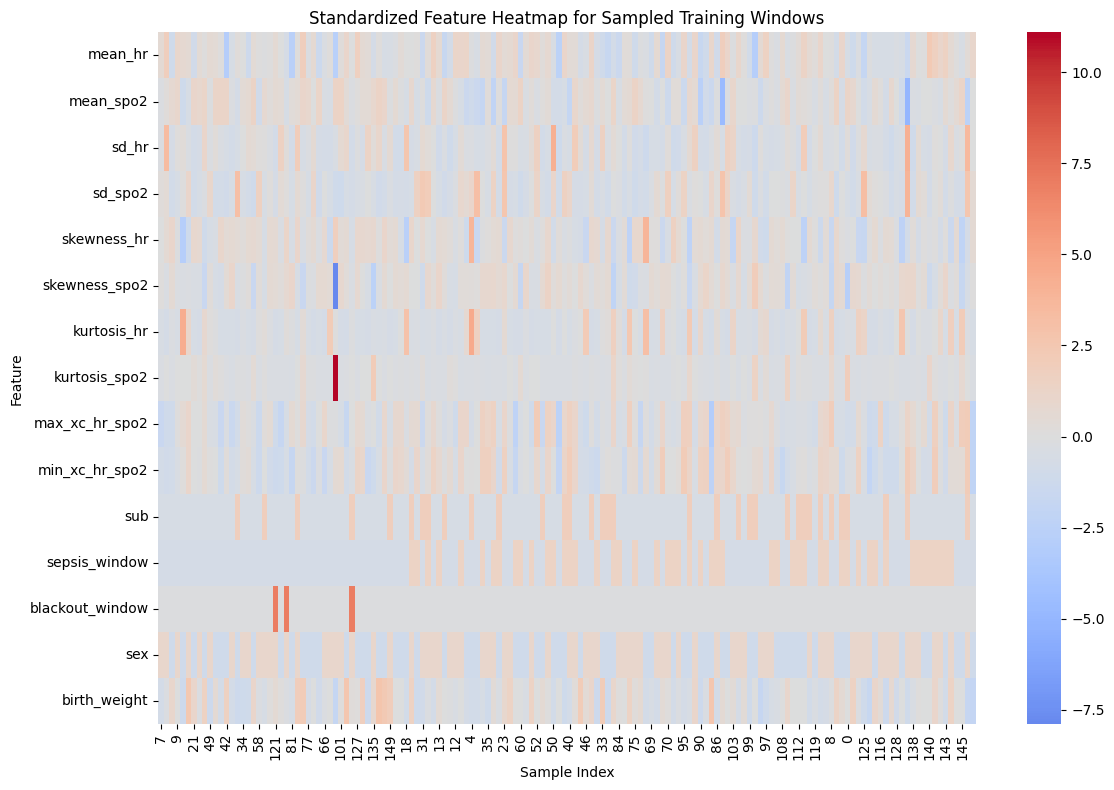

In [33]:
heatmap_sample = dfs["train"].sample(n=min(150, len(dfs["train"])), random_state=42).copy()

X_heat = heatmap_sample[feature_cols].fillna(0)
X_heat_scaled = StandardScaler().fit_transform(X_heat)

heatmap_scaled_df = pd.DataFrame(X_heat_scaled, columns=feature_cols)
heatmap_scaled_df["Class"] = heatmap_sample[TARGET].values
heatmap_scaled_df = heatmap_scaled_df.sort_values("Class").drop(columns="Class")

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_scaled_df.T, cmap="coolwarm", center=0)
plt.title("Standardized Feature Heatmap for Sampled Training Windows")
plt.xlabel("Sample Index")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

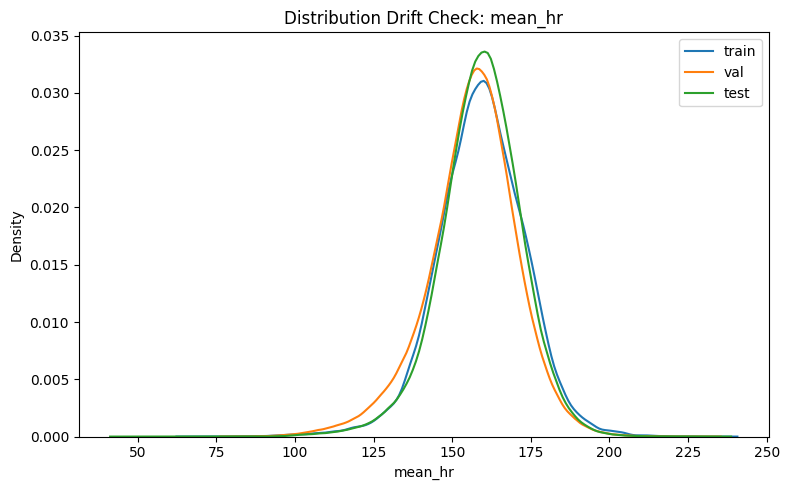

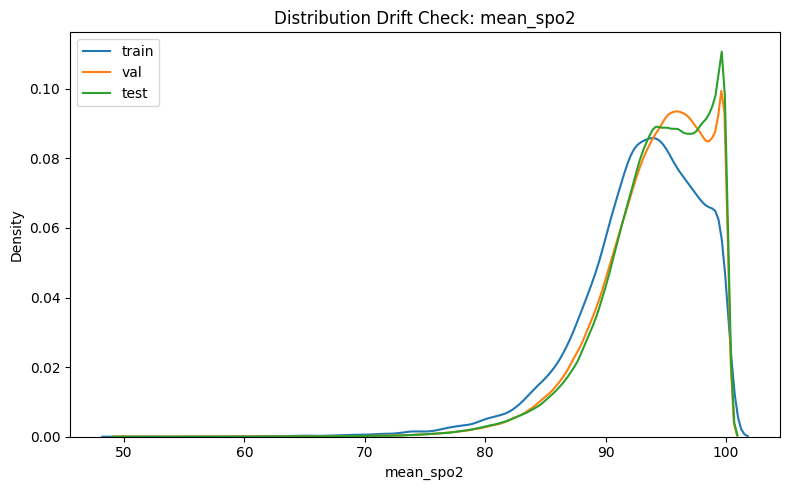

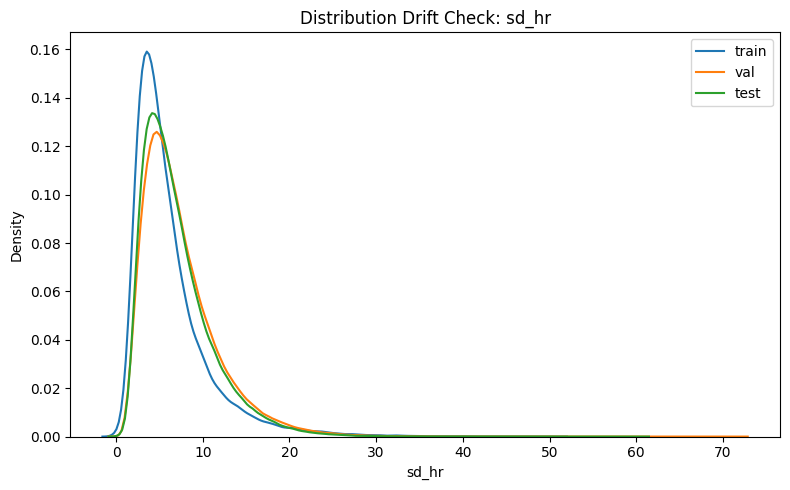

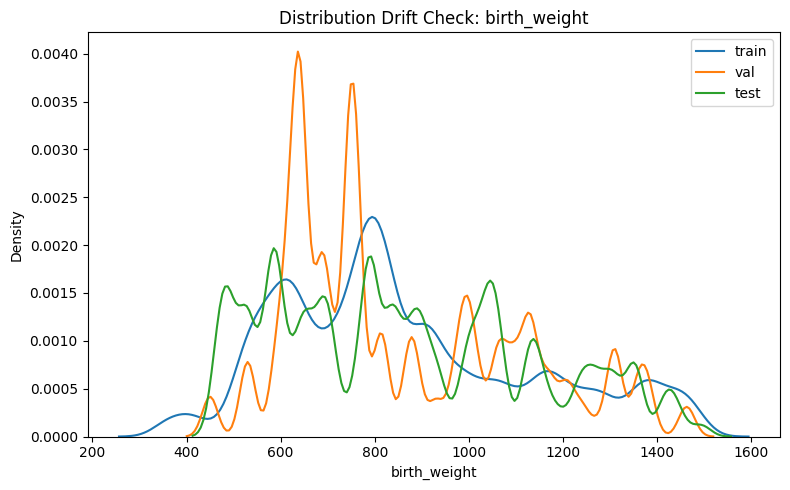

In [34]:
drift_features = [c for c in ["mean_hr", "mean_spo2", "sd_hr", "birth_weight"] if c in feature_cols]

for feat in drift_features:
    plt.figure(figsize=(8, 5))
    sns.kdeplot(dfs["train"][feat], label="train")
    sns.kdeplot(dfs["val"][feat], label="val")
    sns.kdeplot(dfs["test"][feat], label="test")
    plt.title(f"Distribution Drift Check: {feat}")
    plt.xlabel(feat)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [35]:
top_features = mi_df.head(10)["Feature"].tolist()

summary_stats = dfs["train"].groupby(TARGET)[top_features].mean().T
summary_stats.columns = ["Class_0_Mean", "Class_1_Mean"]
summary_stats["Difference"] = summary_stats["Class_1_Mean"] - summary_stats["Class_0_Mean"]

summary_stats.sort_values("Difference", ascending=False)

,Class_0_Mean,Class_1_Mean,Difference
kurtosis_hr,6.038083,7.537240,1.499157
sepsis_window,0.000322,0.505004,0.504682
skewness_spo2,-1.354657,-0.908158,0.446500
min_xc_hr_spo2,-0.265656,-0.197572,0.068084
sub,0.170796,0.167771,-0.003025
skewness_hr,-0.286141,-0.858362,-0.572221
sd_hr,7.038827,5.843494,-1.195333
kurtosis_spo2,7.426929,4.863274,-2.563656
mean_spo2,94.695619,91.859935,-2.835684
birth_weight,960.401313,815.016899,-145.384414


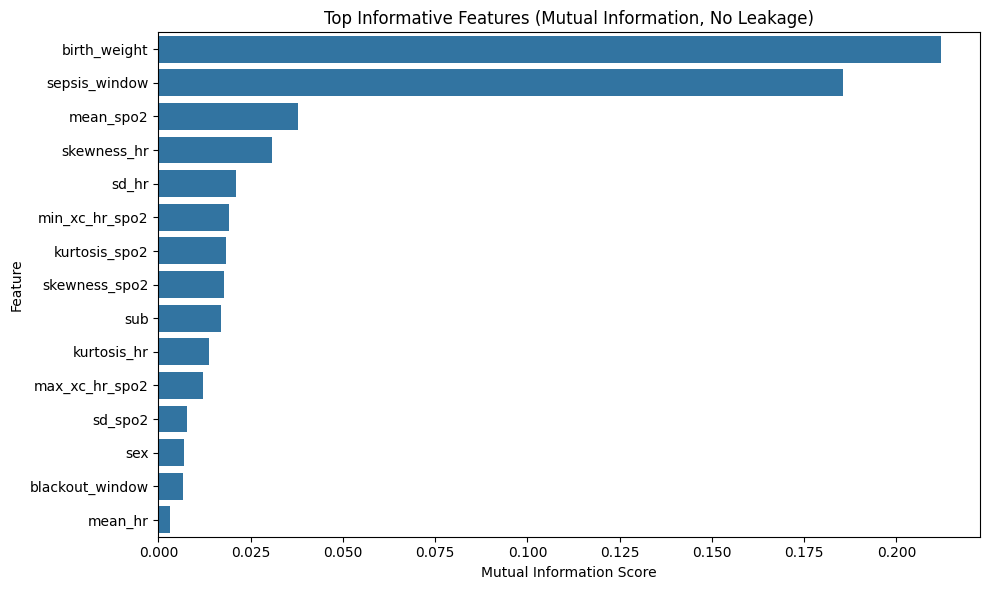

Saved figures to: C:\Users\96277\nicu-sepsis\eda_outputs


In [36]:
output_dir = Path("eda_outputs")
output_dir.mkdir(exist_ok=True)

# Example save for one figure
plt.figure(figsize=(10, 6))
sns.barplot(data=mi_df.head(15), x="MI_Score", y="Feature")
plt.title("Top Informative Features (Mutual Information, No Leakage)")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(output_dir / "mutual_information_top_features.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figures to: {output_dir.resolve()}")

In [37]:
print("""
EDA Key Notes:
1. The training set is intentionally resampled, producing higher sepsis prevalence than validation/test.
2. Only physiological features were used for analysis; identifier/meta columns were excluded to avoid data leakage.
3. Several features (e.g., mean_hr, mean_spo2, birth_weight) show class-dependent distributional differences.
4. Correlation and manifold visualizations suggest partial separability with substantial overlap, reflecting the difficulty of early sepsis prediction.
5. Mutual information highlights the most statistically informative pre-modeling features.
""")


EDA Key Notes:
1. The training set is intentionally resampled, producing higher sepsis prevalence than validation/test.
2. Only physiological features were used for analysis; identifier/meta columns were excluded to avoid data leakage.
3. Several features (e.g., mean_hr, mean_spo2, birth_weight) show class-dependent distributional differences.
4. Correlation and manifold visualizations suggest partial separability with substantial overlap, reflecting the difficulty of early sepsis prediction.
5. Mutual information highlights the most statistically informative pre-modeling features.

